ambiente anaconda

In [1]:
import sys
print(sys.executable)

/home/fabiene/anaconda3/envs/Udemy/bin/python


In [2]:
# versão do python
print(sys.version)

3.11.9 (main, Apr 19 2024, 16:48:06) [GCC 11.2.0]


# 31 exercício

In [7]:
# caso precise conectar ao colab

# from google.colab import drive
# drive.mount('/content/drive')

# import os

# DRIVE_DIRECTORY = "curso_ml" # aqui defina o nome/caminho da pasta no seu Drive que vai armazenar os arquivos.
# DRIVE_DIRECTORY = os.path.join("/content/drive/MyDrive", DRIVE_DIRECTORY)
# if not os.path.exists(DRIVE_DIRECTORY):
#     os.makedirs(DRIVE_DIRECTORY) # a pasta será criada se não existir

In [4]:
import pickle

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.compose import ColumnTransformer
from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

# 31) Base de dados cobertura vegetal

## Download e preparação dos dados

Neste exercício, você vai utilizar um dataset real. Nesta primeira etapa, ao invés de carregar um arquivo no ambiente de computação, nós vamos fazer o download e a preparação dos dados, utilizando uma função do Scikit-Learn.

Se você não quiser fazer essa parte, pode simplesmente rodar essa seção e ir direto para os exercícios!


Documentação do dataset: https://archive.ics.uci.edu/dataset/31/covertype

Documentação da função do Scikit-Learn: https://scikit-learn.org/stable/datasets/real_world.html#covtype-dataset

> As amostras neste conjunto de dados correspondem a trechos de 30×30m de floresta nos EUA, coletados para a tarefa de prever o tipo de cobertura de cada trecho, ou seja, a espécie dominante de árvore. Existem sete tipos de cobertura, tornando este um problema de classificação multiclasse. Cada amostra possui 54 características, descritas na página inicial do conjunto de dados. Algumas das características são indicadores booleanos, enquanto outras são medições discretas ou contínuas.
>
> **Características do Conjunto de Dados:**
>
> - **Classes:** 7  
> - **Total de amostras:** 581012  
> - **Dimensionalidade:** 54  
> - **Características:** Inteiras  


In [5]:
data = fetch_covtype(as_frame=True).frame
data

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39,Cover_Type
0,2596.0,51.0,3.0,258.0,0.0,510.0,221.0,232.0,148.0,6279.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
1,2590.0,56.0,2.0,212.0,-6.0,390.0,220.0,235.0,151.0,6225.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
2,2804.0,139.0,9.0,268.0,65.0,3180.0,234.0,238.0,135.0,6121.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
3,2785.0,155.0,18.0,242.0,118.0,3090.0,238.0,238.0,122.0,6211.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
4,2595.0,45.0,2.0,153.0,-1.0,391.0,220.0,234.0,150.0,6172.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
581007,2396.0,153.0,20.0,85.0,17.0,108.0,240.0,237.0,118.0,837.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
581008,2391.0,152.0,19.0,67.0,12.0,95.0,240.0,237.0,119.0,845.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
581009,2386.0,159.0,17.0,60.0,7.0,90.0,236.0,241.0,130.0,854.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
581010,2384.0,170.0,15.0,60.0,5.0,90.0,230.0,245.0,143.0,864.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3


# padronizar os dados como puros

Perceba que este dataframe contém 55 colunas, sendo que a última (`Cover_Type`) corresponde à variável alvo.

Neste dataset, alguns atributos categóricos já vêm no formato One Hot Encoded, mais especificamente aqueles relacionados a `Wilderness_Area` e `Soil_Type`. Para que você possa praticar a aplicação da técnica de One Hot Encoding, nas duas próximas células nós estamos "desfazendo" esta formatação. Não se preocupe muito com o código, mas se você quiser entender melhor o que está acontecendo, recomendamos utilizar o recurso *Explicar o código* do Gemini no Google Colab:

> 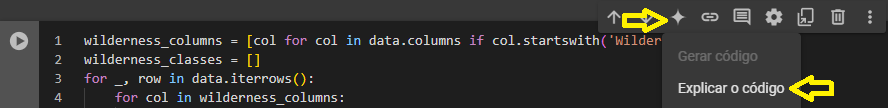

In [9]:
list(data.columns)

['Elevation',
 'Aspect',
 'Slope',
 'Horizontal_Distance_To_Hydrology',
 'Vertical_Distance_To_Hydrology',
 'Horizontal_Distance_To_Roadways',
 'Hillshade_9am',
 'Hillshade_Noon',
 'Hillshade_3pm',
 'Horizontal_Distance_To_Fire_Points',
 'Wilderness_Area_0',
 'Wilderness_Area_1',
 'Wilderness_Area_2',
 'Wilderness_Area_3',
 'Soil_Type_0',
 'Soil_Type_1',
 'Soil_Type_2',
 'Soil_Type_3',
 'Soil_Type_4',
 'Soil_Type_5',
 'Soil_Type_6',
 'Soil_Type_7',
 'Soil_Type_8',
 'Soil_Type_9',
 'Soil_Type_10',
 'Soil_Type_11',
 'Soil_Type_12',
 'Soil_Type_13',
 'Soil_Type_14',
 'Soil_Type_15',
 'Soil_Type_16',
 'Soil_Type_17',
 'Soil_Type_18',
 'Soil_Type_19',
 'Soil_Type_20',
 'Soil_Type_21',
 'Soil_Type_22',
 'Soil_Type_23',
 'Soil_Type_24',
 'Soil_Type_25',
 'Soil_Type_26',
 'Soil_Type_27',
 'Soil_Type_28',
 'Soil_Type_29',
 'Soil_Type_30',
 'Soil_Type_31',
 'Soil_Type_32',
 'Soil_Type_33',
 'Soil_Type_34',
 'Soil_Type_35',
 'Soil_Type_36',
 'Soil_Type_37',
 'Soil_Type_38',
 'Soil_Type_39',
 'Cov

In [10]:
# retirar o one hot encoded das colunas Wilderness_Area e Soil_Type
data['Wilderness_Area_0'].tail()

581007    0.0
581008    0.0
581009    0.0
581010    0.0
581011    0.0
Name: Wilderness_Area_0, dtype: float64

In [11]:
data['Soil_Type_0'].tail()

581007    0.0
581008    0.0
581009    0.0
581010    0.0
581011    0.0
Name: Soil_Type_0, dtype: float64

reverter o One-Hot Encoding.

Basicamente, ele pega várias colunas que representam a mesma categoria (onde apenas uma tem o valor 1 e as outras 0) e as transforma em uma única coluna numérica.

In [12]:
#1. Identificação das Colunas
#O código cria uma lista com todos os nomes de colunas que começam com "Wilderness_Area" 
#(ex: Wilderness_Area_1, Wilderness_Area_2, etc).
wilderness_columns = [col for col in data.columns if col.startswith('Wilderness_Area')]

wilderness_classes = []
for _, row in data.iterrows():
    for col in wilderness_columns:
        if row[col] == 1:
            #2. Busca pelo valor Ativo (Onde está o "1")
            wilderness_classes.append(int(col.split('_')[-1]))
            break

# Ele percorre linha por linha do seu conjunto de dados.
# Para cada linha, ele checa qual das colunas de "Wilderness" tem o valor 1.
# Quando encontra, ele "limpa" o nome da coluna (ex: de Wilderness_Area_3 ele pega apenas o 3) 
# e guarda esse número em uma lista chamada wilderness_classes.

#3. Substituição no DataFrame
# Drop: Ele apaga as várias colunas originais (as colunas "espalhadas").
# Insert: Ele cria uma nova coluna única chamada Wilderness_Area 
# e preenche com os números que ele extraiu. Ele insere essa coluna na penúltima posição do DataFrame.    
data.drop(columns=wilderness_columns, inplace=True)
data.insert(len(data.columns)-1, 'Wilderness_Area', wilderness_classes)

# Consolida múltiplas colunas binárias em uma única coluna numérica categórica.

In [13]:
# # maneira mais rápida
# # Versão ultra rápida (vetorizada)
# data['Wilderness_Area'] = data[wilderness_columns].idxmax(axis=1).str.split('_').str[-1].astype(int)
# data.drop(columns=wilderness_columns, inplace=True)

In [17]:
data['Wilderness_Area'].tail(5)

581007    2
581008    2
581009    2
581010    2
581011    2
Name: Wilderness_Area, dtype: int64

In [18]:
list(data['Wilderness_Area'].unique())

[np.int64(0), np.int64(2), np.int64(3), np.int64(1)]

In [19]:
soil_type_columns = [col for col in data.columns if col.startswith('Soil_Type')]
soil_type_classes = []
for _, row in data.iterrows():
    for col in soil_type_columns:
        if row[col] == 1:
            soil_type_classes.append(int(col.split('_')[-1]))
            break
data.drop(columns=soil_type_columns, inplace=True)
data.insert(len(data.columns)-1, 'Soil_Type', soil_type_classes)

In [20]:
list(data['Soil_Type'].unique())

[np.int64(28),
 np.int64(11),
 np.int64(29),
 np.int64(17),
 np.int64(15),
 np.int64(19),
 np.int64(23),
 np.int64(22),
 np.int64(39),
 np.int64(18),
 np.int64(7),
 np.int64(21),
 np.int64(38),
 np.int64(8),
 np.int64(37),
 np.int64(32),
 np.int64(30),
 np.int64(31),
 np.int64(10),
 np.int64(9),
 np.int64(4),
 np.int64(27),
 np.int64(3),
 np.int64(0),
 np.int64(12),
 np.int64(1),
 np.int64(16),
 np.int64(2),
 np.int64(33),
 np.int64(5),
 np.int64(13),
 np.int64(36),
 np.int64(34),
 np.int64(35),
 np.int64(20),
 np.int64(25),
 np.int64(26),
 np.int64(24),
 np.int64(6),
 np.int64(14)]

## os dados serão convertidos para string

A variável alvo, `Cover_Type`, também já está no formato Label Encoded. Vamos converter para o nome original das plantas, utilizando a informação presente na documentação do dataset:

> Cover_Type (7 types) / integer / 1 to 7 / Forest Cover Type designation
>
> Class Labels: Spruce/Fir, Lodgepole Pine, Ponderosa Pine, Cottonwood/Willow, Aspen, Douglas-fir, Krummholz

In [21]:
class_labels = ["Spruce/Fir", "Lodgepole Pine", "Ponderosa Pine", "Cottonwood/Willow", "Aspen", "Douglas-fir", "Krummholz"]
class_labels_dict = {i: label for i, label in enumerate(class_labels, start=1)}
data['Cover_Type'] = data['Cover_Type'].map(class_labels_dict)

In [22]:
data.tail()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area,Soil_Type,Cover_Type
581007,2396.0,153.0,20.0,85.0,17.0,108.0,240.0,237.0,118.0,837.0,2,1,Ponderosa Pine
581008,2391.0,152.0,19.0,67.0,12.0,95.0,240.0,237.0,119.0,845.0,2,1,Ponderosa Pine
581009,2386.0,159.0,17.0,60.0,7.0,90.0,236.0,241.0,130.0,854.0,2,1,Ponderosa Pine
581010,2384.0,170.0,15.0,60.0,5.0,90.0,230.0,245.0,143.0,864.0,2,1,Ponderosa Pine
581011,2383.0,165.0,13.0,60.0,4.0,67.0,231.0,244.0,141.0,875.0,2,1,Ponderosa Pine


Uma última etapa: este dataset é bastante extenso, contendo 581012 linhas. Alguns algoritmos podem levar muito tempo para treinar com tantos dados, e algumas técnicas que vamos utilizar treinam o algoritmo mais de uma vez. Então, vamos limitar este estudo a 10000 exemplos, amostrados aleatoriamente a partir da base completa.

## reduzir a quantidade de linha para fazer o exercício

In [23]:
data = data.sample(10000, random_state=0)

In [26]:
data.head() # amostra, sample pega linhas aleatórias.

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area,Soil_Type,Cover_Type
215988,2767.0,66.0,17.0,210.0,18.0,1190.0,234.0,204.0,96.0,2251.0,2,30,Lodgepole Pine
424155,2724.0,160.0,19.0,60.0,4.0,1350.0,236.0,240.0,127.0,2514.0,2,16,Lodgepole Pine
274437,2360.0,65.0,7.0,127.0,21.0,1377.0,227.0,226.0,134.0,339.0,3,5,Ponderosa Pine
65944,2995.0,45.0,4.0,285.0,30.0,5125.0,221.0,231.0,146.0,5706.0,0,11,Lodgepole Pine
11015,2400.0,106.0,27.0,150.0,63.0,342.0,253.0,196.0,51.0,811.0,2,3,Ponderosa Pine


Finalmente, vamos salvar os dados em um arquivo, para você utilizar como base neste e em outros exercícios.

In [28]:
import os
DRIVE_DIRECTORY = ''

In [29]:
data.to_csv(os.path.join(DRIVE_DIRECTORY, 'cov_types_reduzido_exer3.csv'), index=False)

## Exploração dos dados

## 32.0) Carregue os dados a partir do arquivo csv, em um dataframe do Pandas.

In [30]:
base = pd.read_csv(os.path.join(DRIVE_DIRECTORY, 'cov_types_reduzido_exer3.csv'))

In [33]:
# os 15 últimos dados
base.tail(15)

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area,Soil_Type,Cover_Type
9985,3246.0,309.0,15.0,430.0,119.0,3578.0,177.0,229.0,192.0,1894.0,2,30,Spruce/Fir
9986,3199.0,293.0,12.0,466.0,81.0,876.0,185.0,237.0,192.0,700.0,2,22,Lodgepole Pine
9987,3388.0,94.0,12.0,607.0,155.0,1848.0,239.0,221.0,110.0,1790.0,0,34,Krummholz
9988,3210.0,43.0,8.0,0.0,0.0,124.0,222.0,223.0,136.0,830.0,1,15,Lodgepole Pine
9989,3317.0,63.0,10.0,30.0,-2.0,2873.0,229.0,221.0,124.0,1806.0,2,37,Krummholz
9990,2788.0,20.0,9.0,30.0,2.0,3555.0,214.0,221.0,143.0,2984.0,0,22,Spruce/Fir
9991,2899.0,84.0,17.0,85.0,21.0,1176.0,242.0,208.0,90.0,1664.0,0,29,Lodgepole Pine
9992,3517.0,270.0,5.0,459.0,70.0,1445.0,207.0,241.0,173.0,1937.0,1,39,Krummholz
9993,2942.0,351.0,10.0,391.0,29.0,5337.0,203.0,224.0,159.0,2105.0,0,28,Lodgepole Pine
9994,2055.0,327.0,19.0,30.0,14.0,532.0,169.0,215.0,183.0,684.0,3,13,Douglas-fir


In [36]:
list(base.columns)

['Elevation',
 'Aspect',
 'Slope',
 'Horizontal_Distance_To_Hydrology',
 'Vertical_Distance_To_Hydrology',
 'Horizontal_Distance_To_Roadways',
 'Hillshade_9am',
 'Hillshade_Noon',
 'Hillshade_3pm',
 'Horizontal_Distance_To_Fire_Points',
 'Wilderness_Area',
 'Soil_Type',
 'Cover_Type']

In [39]:
print(f'quantidade de colunas: {len(list(base.columns))}.')

quantidade de colunas: 13.


In [34]:
base.head(10) # os 10 primeiros dados do .csv

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area,Soil_Type,Cover_Type
0,2767.0,66.0,17.0,210.0,18.0,1190.0,234.0,204.0,96.0,2251.0,2,30,Lodgepole Pine
1,2724.0,160.0,19.0,60.0,4.0,1350.0,236.0,240.0,127.0,2514.0,2,16,Lodgepole Pine
2,2360.0,65.0,7.0,127.0,21.0,1377.0,227.0,226.0,134.0,339.0,3,5,Ponderosa Pine
3,2995.0,45.0,4.0,285.0,30.0,5125.0,221.0,231.0,146.0,5706.0,0,11,Lodgepole Pine
4,2400.0,106.0,27.0,150.0,63.0,342.0,253.0,196.0,51.0,811.0,2,3,Ponderosa Pine
5,2656.0,20.0,9.0,323.0,73.0,1082.0,214.0,221.0,143.0,1036.0,0,11,Lodgepole Pine
6,2992.0,105.0,36.0,201.0,141.0,1211.0,252.0,170.0,12.0,1584.0,2,32,Spruce/Fir
7,3110.0,32.0,14.0,379.0,43.0,5028.0,216.0,208.0,125.0,2845.0,0,29,Spruce/Fir
8,3242.0,40.0,15.0,85.0,19.0,3330.0,220.0,207.0,118.0,3164.0,2,23,Lodgepole Pine
9,3025.0,273.0,10.0,391.0,24.0,2797.0,192.0,243.0,190.0,234.0,0,21,Spruce/Fir


Exiba as estatísticas básicas da base.

In [35]:
base.describe()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area,Soil_Type
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2966.946400,153.860000,14.148400,270.744400,46.610200,2357.047800,212.520300,223.253900,141.993600,1986.776600,1.107900,23.584100
std,278.877757,111.313091,7.467714,211.481433,58.188252,1564.031388,26.642597,19.851419,38.458979,1324.588532,1.058097,9.413001
min,1893.000000,0.000000,0.000000,0.000000,-132.000000,0.000000,60.000000,104.000000,0.000000,0.000000,0.000000,0.000000
25%,2820.000000,58.000000,9.000000,108.000000,7.000000,1092.000000,199.000000,213.000000,119.000000,1034.000000,0.000000,19.000000
50%,3004.000000,125.000000,13.000000,218.000000,30.000000,2012.000000,218.000000,226.000000,143.000000,1711.000000,1.000000,28.000000
75%,3167.000000,255.000000,18.000000,390.000000,69.000000,3347.000000,231.000000,237.000000,168.000000,2556.000000,2.000000,30.000000
max,3845.000000,360.000000,55.000000,1376.000000,573.000000,6926.000000,254.000000,254.000000,250.000000,7150.000000,3.000000,39.000000


In [42]:
# soma, média, desvio padrão, máximo e mínimo e quartis.

Os quartis de $\(25\%\)$, $\(50\%\)$ e $\(75\%\)$ são medidas estatísticas que dividem um conjunto de dados ordenado em quatro partes iguais, representadas respectivamente por $\(Q_{1}\)$ (Primeiro Quartil), $\(Q_{2}\)$ (Mediana) e $\(Q_{3}\)$ (Terceiro Quartil). 

## Visualização dos dados

### Exiba o nome das categorias de tipo de cobertura vegetal e sua frequência.

In [43]:
np.unique(base["Cover_Type"], return_counts=True)

(array(['Aspen', 'Cottonwood/Willow', 'Douglas-fir', 'Krummholz',
        'Lodgepole Pine', 'Ponderosa Pine', 'Spruce/Fir'], dtype=object),
 array([ 163,   55,  278,  362, 4847,  581, 3714]))

### Exiba a mesma informação, mas como um gráfico de barras.

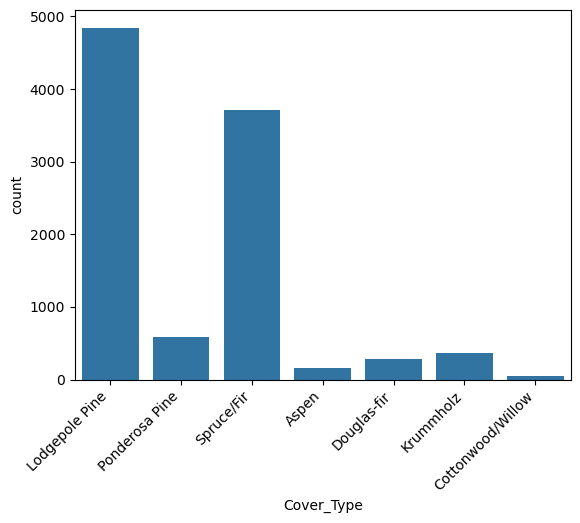

In [44]:
sns.countplot(x=base["Cover_Type"])
# Mantenha a próxima linha para rotacionar os rótulos e facilitar sua leitura
plt.xticks(rotation=45, ha='right');

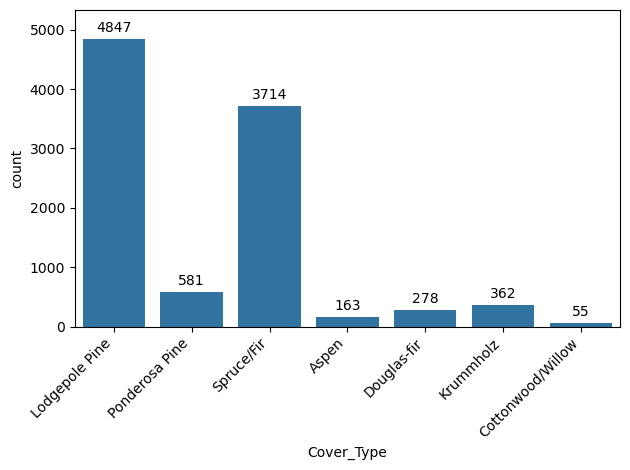

In [47]:
# 1. armazenamos o objeto de eixos (ax)
ax = sns.countplot(x=base["Cover_Type"])

# 2. rótulos em cada barra
# padding=3 adiciona um pequeno espaço entre a barra e o texto
ax.bar_label(ax.containers[0], padding=3)

# 3. Aumenta o limite do eixo Y em 10% para o número não bater no teto
# Pegamos o valor máximo atual e multiplicamos por 1.1
y_max = base["Cover_Type"].value_counts().max()
ax.set_ylim(0, y_max * 1.1)

# Sua configuração de rotação
plt.xticks(rotation=45, ha='right')

# Ajusta o layout para não cortar o texto
plt.tight_layout()
plt.show()

### Exiba um histograma para as variáveis numéricas (`Elevation` até `Horizontal_Distance_To_Fire_Points`).

In [49]:
list(base.columns[:-3])

['Elevation',
 'Aspect',
 'Slope',
 'Horizontal_Distance_To_Hydrology',
 'Vertical_Distance_To_Hydrology',
 'Horizontal_Distance_To_Roadways',
 'Hillshade_9am',
 'Hillshade_Noon',
 'Hillshade_3pm',
 'Horizontal_Distance_To_Fire_Points']

Gerando histograma para: Elevation


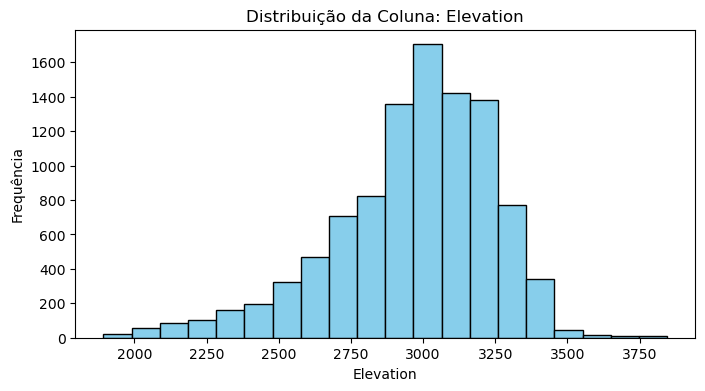

Gerando histograma para: Aspect


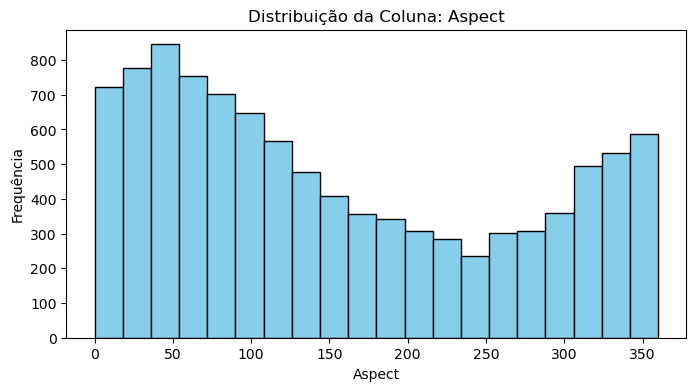

Gerando histograma para: Slope


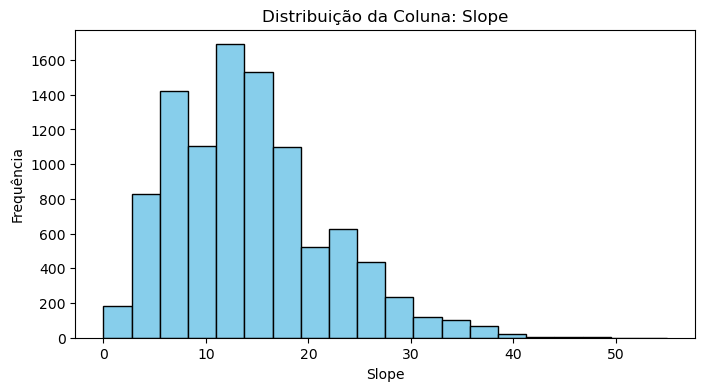

Gerando histograma para: Horizontal_Distance_To_Hydrology


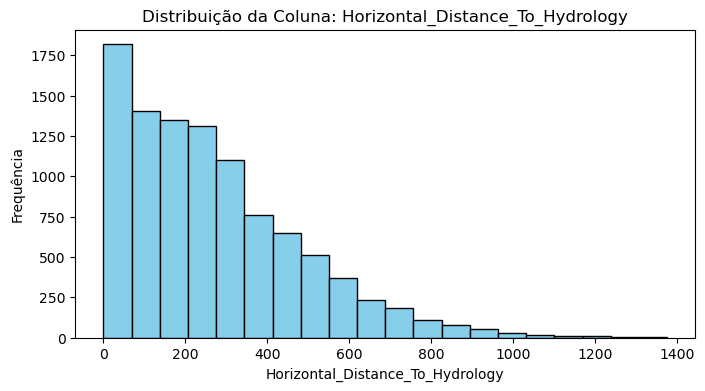

Gerando histograma para: Vertical_Distance_To_Hydrology


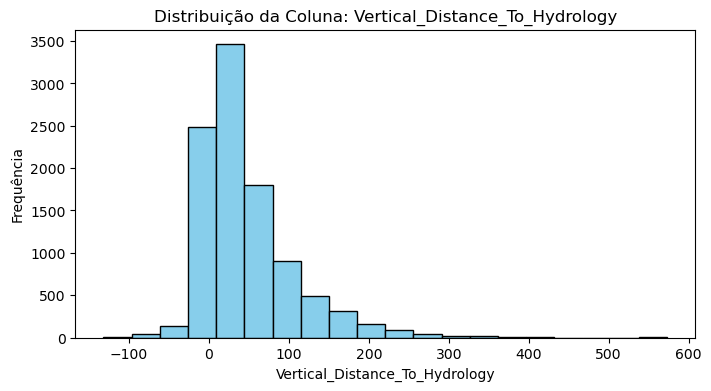

Gerando histograma para: Horizontal_Distance_To_Roadways


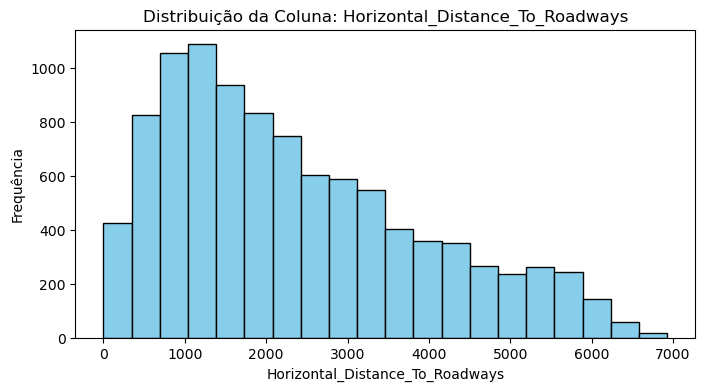

Gerando histograma para: Hillshade_9am


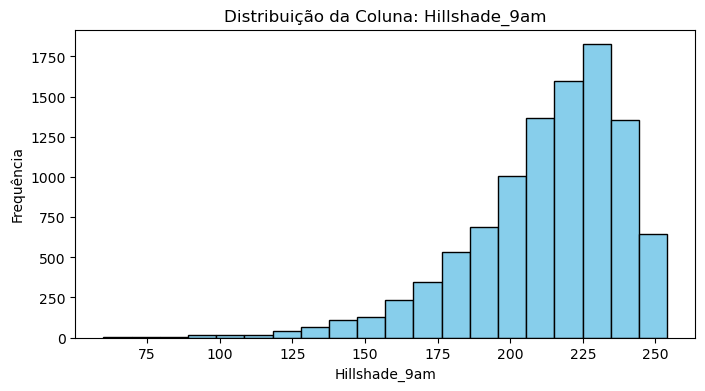

Gerando histograma para: Hillshade_Noon


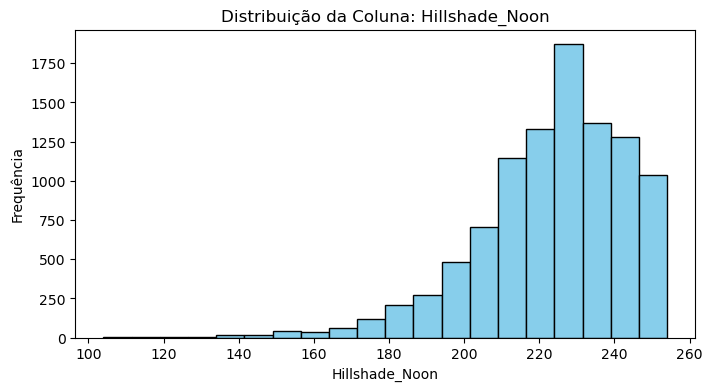

Gerando histograma para: Hillshade_3pm


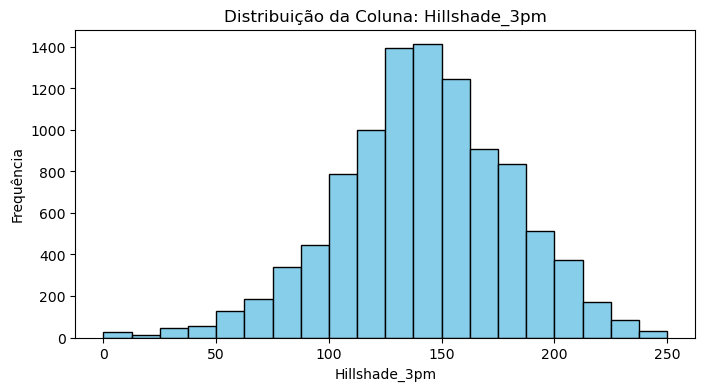

Gerando histograma para: Horizontal_Distance_To_Fire_Points


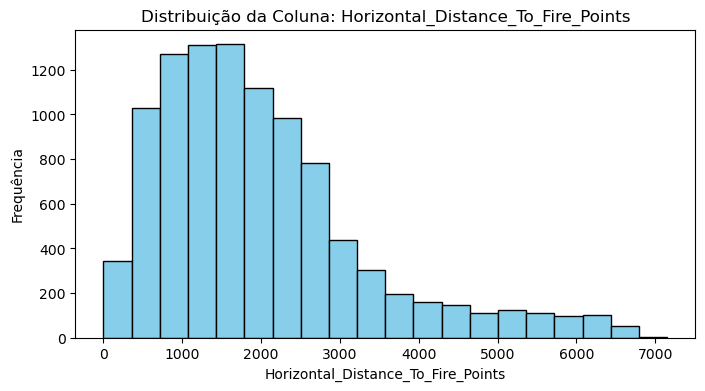

In [54]:
for coluna in list(base.columns[:-3]):
    print(f"Gerando histograma para: {coluna}") # Log no console
    plt.figure(figsize=(8, 4)) # tamanho para o gráfico não ficar pequeno
    plt.hist(x=base[coluna], bins=20, color='skyblue', edgecolor='black')
    #plt.hist(x=base[f"{coluna}"]);
    plt.title(f'Distribuição da Coluna: {coluna}') # Nome no topo
    plt.xlabel(coluna)                             # Nome no eixo X
    plt.ylabel('Frequência')                       # Nome no eixo Y
    plt.show()

### Exiba um grid com gráficos de correlação entre as variáveis numéricas. Use `Cover_Type` para codificar as cores.

# matriz de correlação dinâmica

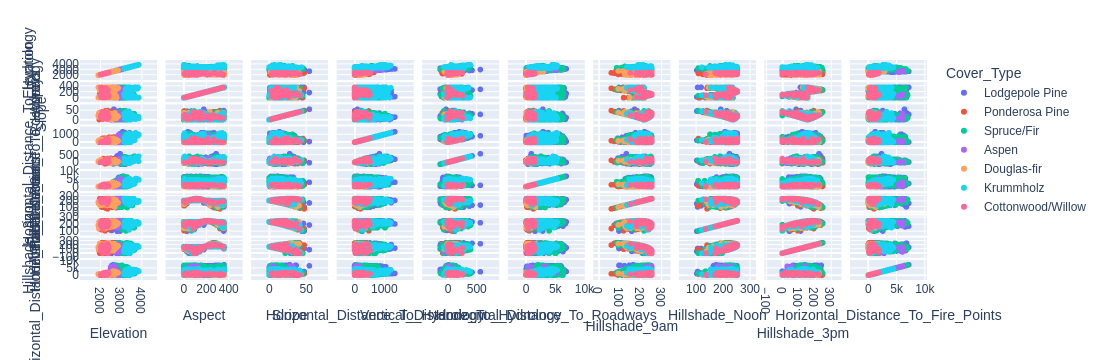

Gráfico salvo com sucesso como 'analise_cover_type.html'!


In [56]:
fig = px.scatter_matrix(base,
                        dimensions=['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
                                    'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
                                    'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
                                    'Horizontal_Distance_To_Fire_Points'],
                        color='Cover_Type')
fig.show()
fig.write_html("analise_cover_type.html")
print("Gráfico salvo com sucesso como 'analise_cover_type.html'!")

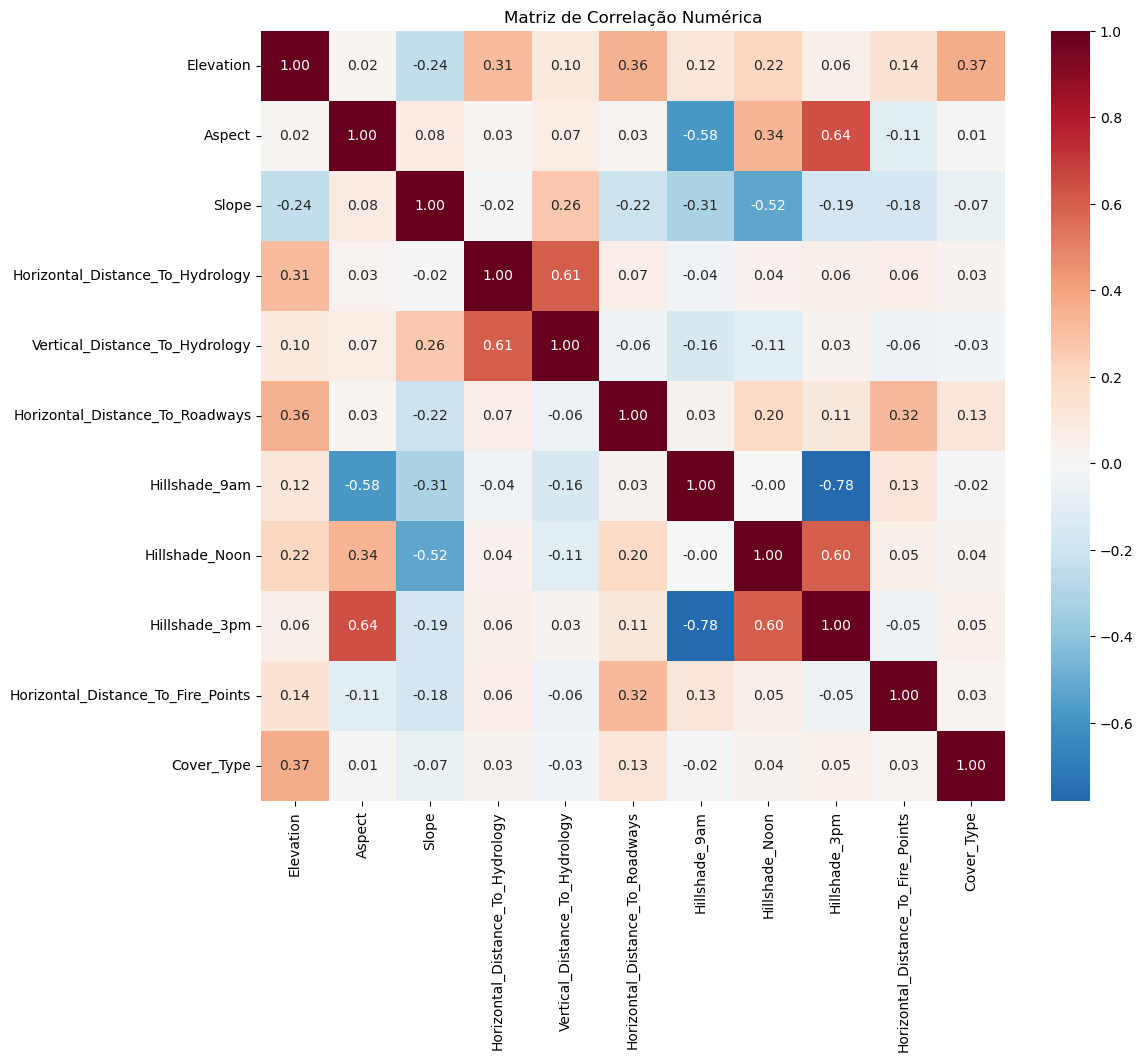

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

colunas_analise = [
    'Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
    'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
    'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
    'Horizontal_Distance_To_Fire_Points', 'Cover_Type'
]

# 1. Criar uma cópia para não estragar os dados originais
base_grafico = base[colunas_analise].copy()

# 2. Converter Cover_Type para numérico se for texto
if base_grafico['Cover_Type'].dtype == 'object':
    # Transforma 'Lodgepole Pine' em 1, 'Spruce/Fir' em 2, etc.
    base_grafico['Cover_Type'] = base_grafico['Cover_Type'].astype('category').cat.codes

# 3. Calcular a correlação
corr = base_grafico.corr()

# 4. Plotar o Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='RdBu_r', center=0)
plt.title('Matriz de Correlação Numérica')
plt.show()

## Divisão entre previsores e classe

Separe as variáveis preditoras em uma variável `X`, no formato de NumPy array. Como a variável alvo é a última coluna, você pode selecionar as variáveis preditoras com a notação `:-1`, que significa "desde o início até o penúltimo".

#### separar os previsores e as classes

In [60]:
base.columns

Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area', 'Soil_Type',
       'Cover_Type'],
      dtype='object')

In [68]:
base.columns[:-1] # colunas como base para a previsão, ou seja os previsores

Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area', 'Soil_Type'],
      dtype='object')

In [62]:
base.columns[-1]

'Cover_Type'

In [65]:
X = base.iloc[:, :-1].values # classes na variável

Exiba estes valores.

In [67]:
X # formato do numpy array

array([[2.767e+03, 6.600e+01, 1.700e+01, ..., 2.251e+03, 2.000e+00,
        3.000e+01],
       [2.724e+03, 1.600e+02, 1.900e+01, ..., 2.514e+03, 2.000e+00,
        1.600e+01],
       [2.360e+03, 6.500e+01, 7.000e+00, ..., 3.390e+02, 3.000e+00,
        5.000e+00],
       ...,
       [3.052e+03, 7.900e+01, 1.900e+01, ..., 1.490e+03, 2.000e+00,
        2.200e+01],
       [2.958e+03, 5.800e+01, 6.000e+00, ..., 2.280e+03, 0.000e+00,
        2.800e+01],
       [2.682e+03, 9.100e+01, 1.300e+01, ..., 1.661e+03, 2.000e+00,
        1.000e+01]], shape=(10000, 12))

Separe a variável alvo em uma variável `y`, também como NumPy array. Você também pode usar a notação `-1`, que neste contexto significa "última coluna".

In [70]:
base.columns[-1] # a coluna de interesse, o target, ou seja a classe é esta

'Cover_Type'

In [71]:
y = base.iloc[:, -1].values

Exiba os valores.

In [73]:
y # string alvo

array(['Lodgepole Pine', 'Lodgepole Pine', 'Ponderosa Pine', ...,
       'Spruce/Fir', 'Lodgepole Pine', 'Lodgepole Pine'],
      shape=(10000,), dtype=object)

## Tratamento da variável alvo (LabelEncoder)

De acordo com a [documentação mais recente](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html), o `LabelEncoder` "deve ser usado para codificar os valores alvo, ou seja `y`, e não a entrada `X`". Isso porque os valores retornados são apenas rótulos, não tendo significado numérico, portanto não sendo úteis para treinar algoritmos. O mesmo se aplica à variável `y`, mas ela pode ser apresentada aos algoritmos do Scikit-Learn no formato *label encoded* porque, internamente, os algoritmos fazem a transformação seguinte, convertendo os rótulos numéricos no formato *one hot encoded*, antes de iniciar os cálculos.

Use a classe `LabelEncoder` para codificar a variável `y`.

In [81]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

In [82]:
y

array([4, 4, 5, ..., 6, 4, 4], shape=(10000,))

In [83]:
# Mostra a lista de nomes na ordem (0, 1, 2...)
print(label_encoder.classes_)

['Aspen' 'Cottonwood/Willow' 'Douglas-fir' 'Krummholz' 'Lodgepole Pine'
 'Ponderosa Pine' 'Spruce/Fir']


In [84]:
mapeamento = dict(zip(range(len(label_encoder.classes_)), label_encoder.classes_))
print(mapeamento)
# Saída esperada: {0: 'Lodgepole Pine', 1: 'Spruce/Fir', 2: 'Ponderosa Pine', ...}

{0: 'Aspen', 1: 'Cottonwood/Willow', 2: 'Douglas-fir', 3: 'Krummholz', 4: 'Lodgepole Pine', 5: 'Ponderosa Pine', 6: 'Spruce/Fir'}


## Tratamento das variáveis preditoras (StandardScaler e OneHotEncoder)

A variável `X` agora contém 12 colunas, sendo aquelas de índice 0 a 9 numéricas, e as de índice 10 e 11 categóricas.

Para dar seguimento ao processamento, as variáveis numéricas devem ser escalonadas, e as variáveis categóricas devem ser transformadas usando One Hot Encoding.

Nós podemos fazer essas duas operações de uma única vez, passando ambos os transformadores para a classe `ColumnTransformer`.

Crie este encoder, usando dois transformadores. O primeiro deve ser uma instância de `StandardScaler`, e deve receber os índices das colunas numéricas (dica: ao invés de passar uma lista de inteiros, você pode indicar os índices com o construtor `slice(0, 10)`, que corresponde a extrair aos índices `[0:10]`), e o segundo deve ser uma instância de `OneHotEncoder`, recebendo os índices das colunas categóricas. Ao construtor de `OneHotEncoder`, informe o parâmetro `sparse_output=False`, para garantir que o resultado não seja expresso como uma matriz esparsa. Como neste caso todas as colunas estão sendo transformadas, o parâmetro `remainder` de `ColumnTransformer` não é necessário.

Em seguida, transforme `X` usando este encoder.

In [85]:
list(base.columns)

['Elevation',
 'Aspect',
 'Slope',
 'Horizontal_Distance_To_Hydrology',
 'Vertical_Distance_To_Hydrology',
 'Horizontal_Distance_To_Roadways',
 'Hillshade_9am',
 'Hillshade_Noon',
 'Hillshade_3pm',
 'Horizontal_Distance_To_Fire_Points',
 'Wilderness_Area',
 'Soil_Type',
 'Cover_Type']

In [86]:
list(base.columns[0:10])

['Elevation',
 'Aspect',
 'Slope',
 'Horizontal_Distance_To_Hydrology',
 'Vertical_Distance_To_Hydrology',
 'Horizontal_Distance_To_Roadways',
 'Hillshade_9am',
 'Hillshade_Noon',
 'Hillshade_3pm',
 'Horizontal_Distance_To_Fire_Points']

In [89]:
list(base.columns[10:12]) # processo categórico

['Wilderness_Area', 'Soil_Type']

In [90]:
base['Wilderness_Area'].unique()

array([2, 3, 0, 1])

In [91]:
base['Soil_Type'].unique() # processo

array([30, 16,  5, 11,  3, 32, 29, 23, 21, 31, 38, 19, 28,  2,  9, 22, 12,
       39,  1, 10, 18, 37, 34, 17,  0, 26, 25,  4,  8, 13, 27, 20, 33, 15,
       35, 36, 24,  7,  6])

In [92]:
data['Soil_Type'].unique()

array([30, 16,  5, 11,  3, 32, 29, 23, 21, 31, 38, 19, 28,  2,  9, 22, 12,
       39,  1, 10, 18, 37, 34, 17,  0, 26, 25,  4,  8, 13, 27, 20, 33, 15,
       35, 36, 24,  7,  6])

In [93]:
data['Wilderness_Area'].unique()

array([2, 3, 0, 1])

In [97]:
len(base.columns)

13

In [94]:
base.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area,Soil_Type,Cover_Type
0,2767.0,66.0,17.0,210.0,18.0,1190.0,234.0,204.0,96.0,2251.0,2,30,Lodgepole Pine
1,2724.0,160.0,19.0,60.0,4.0,1350.0,236.0,240.0,127.0,2514.0,2,16,Lodgepole Pine
2,2360.0,65.0,7.0,127.0,21.0,1377.0,227.0,226.0,134.0,339.0,3,5,Ponderosa Pine
3,2995.0,45.0,4.0,285.0,30.0,5125.0,221.0,231.0,146.0,5706.0,0,11,Lodgepole Pine
4,2400.0,106.0,27.0,150.0,63.0,342.0,253.0,196.0,51.0,811.0,2,3,Ponderosa Pine


In [95]:
# Criamos um transformador para tratar colunas diferentes de formas diferentes
X_encoder = ColumnTransformer(transformers=[
    # 1. Nas colunas de 0 a 9, aplica o StandardScaler (ajusta a escala dos números)
    ('StandardScaler', StandardScaler(), slice(0, 10)),
    
    # 2. Nas colunas 10 e 11, aplica o OneHotEncoder (transforma categorias em colunas 0 e 1)
    ('OneHotEncoder', OneHotEncoder(sparse_output=False), [10, 11])
])

# Aplica todas as transformações acima nos dados X e guarda o resultado
X = X_encoder.fit_transform(X)

In [96]:
X

array([[-0.71700375, -0.78934465,  0.38187624, ...,  0.        ,
         0.        ,  0.        ],
       [-0.87120088,  0.05516249,  0.6497092 , ...,  0.        ,
         0.        ,  0.        ],
       [-2.17649753, -0.79832877, -0.95728858, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.30500049, -0.67255111,  0.6497092 , ...,  0.        ,
         0.        ,  0.        ],
       [-0.03208161, -0.8612176 , -1.09120506, ...,  0.        ,
         0.        ,  0.        ],
       [-1.02181203, -0.56474169, -0.15378969, ...,  0.        ,
         0.        ,  0.        ]], shape=(10000, 53))

In [98]:
X[0]

array([-0.71700375, -0.78934465,  0.38187624, -0.28724714, -0.49170803,
       -0.74621658,  0.80625677, -0.96994893, -1.19597298,  0.19948581,
        0.        ,  0.        ,  1.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  1.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ])

In [100]:
# primeiros dados padronizados de -1 a 1, => StandardScaler
# já as outras colunas é do OneHotEncoder, que vai de 0 a 1

## coluna já pré processada

## Divisão em split de treinamento e teste

Separe as variáveis `X` e `y` em splits para treinamento e teste. Use uma fração de 25% para teste. Fixe a semente de números aleatórios, informando o parâmetro `random_state=0`.

 ### Divisão para 25% para o teste e os outros 75% para treino.

In [102]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y, 
                                                    test_size=0.25,
                                                    random_state=0)

Exiba as dimensões das variáveis do split de treinamento, acessando o atributo `shape`.

In [103]:
X_train.shape, y_train.shape

((7500, 53), (7500,))

Faça o mesmo para o split de teste.

In [104]:
X_test.shape, y_test.shape

((2500, 53), (2500,))

## Salvar as variáveis

Salve as variáveis preditoras e alvo, dos dois splits, em um único arquivo `pickle` com o nome `cover_type.pkl`. A ordem deve ser: primeiro split de treinamento (`X` e `y`), depois split de teste (`X` e `y`).

In [105]:
with open(os.path.join(DRIVE_DIRECTORY, "cover_type_exer3.pkl"), "wb") as f:
    pickle.dump((X_train, y_train, X_test, y_test), f)